# AudioLLM inference

Этот ноутбук только:
1) открывает `artifacts/instruct_data.json` и показывает примеры  
2) загружает **сохранённый адаптер** и делает несколько генераций на примерах

Ожидаемая структура:
- `audio_llm/generate_data.py` → создаёт `artifacts/instruct_data.json`
- `audio_llm/train.py` → обучает и сохраняет `artifacts/runs/<run_name>/adapter.pt`

In [1]:
import json
from pathlib import Path

import numpy as np
import torch
import matplotlib.pyplot as plt
import torchaudio

from audio_llm_lib import AUDIO_TOKEN, load_wav_mono_16k, wav_to_whisper_features, load_adapter_checkpoint

ROOT = Path(".")
ARTIFACTS = ROOT / "artifacts"
DATA_JSON = ARTIFACTS / "instruct_data.json"
print("DATA_JSON exists:", DATA_JSON.exists(), DATA_JSON)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("device:", device)

/opt/python/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


DATA_JSON exists: True artifacts/instruct_data.json
device: cuda


In [2]:
data = json.loads(DATA_JSON.read_text(encoding="utf-8"))
print("samples:", len(data))
data[0].keys(), data[0]["transcription"][:120]

samples: 2497


(dict_keys(['audio_path', 'transcription', 'question', 'answer']),
 'MISTER QUILTER IS THE APOSTLE OF THE MIDDLE CLASSES AND WE ARE GLAD TO WELCOME HIS GOSPEL')

In [3]:
# Пара примеров "как выглядит" запись
for i in range(2):
    s = data[i]
    print("="*80)
    print("audio_path:", s["audio_path"])
    print("Q:", s["question"])
    print("A:", s["answer"])
    print("transcription:", s["transcription"][:160], "...")

audio_path: ../LibriSpeech/dev-clean/1272/128104/1272-128104-0000.flac
Q: Who is Mister Quilter?
A: He is the Apostle of the Middle Classes.
transcription: MISTER QUILTER IS THE APOSTLE OF THE MIDDLE CLASSES AND WE ARE GLAD TO WELCOME HIS GOSPEL ...
audio_path: ../LibriSpeech/dev-clean/1272/128104/1272-128104-0001.flac
Q: How does Mister Quilter's manner compare to his matter?
A: His manner is less interesting than his matter.
transcription: NOR IS MISTER QUILTER'S MANNER LESS INTERESTING THAN HIS MATTER ...


## Загрузка сохранённого адаптера

После обучения скриптом `train.py` у появится папка:

`artifacts/runs/<run_name>/adapter.pt`

In [ ]:
RUN_DIR = ARTIFACTS / "runs" / "early_stopping_full"

print("RUN_DIR exists:", RUN_DIR.exists(), RUN_DIR)
print("adapter exists:", (RUN_DIR/'adapter.pt').exists())

model, fe = load_adapter_checkpoint(RUN_DIR, device=device)
model.eval()
print("loaded. audio_token_id:", model.audio_token_id)

RUN_DIR exists: True artifacts/runs/early_stopping_full
adapter exists: True


/opt/python/lib/python3.10/site-packages/huggingface_hub/file_download.py:1150: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.
  warnings.warn(
Special tokens have been added in the vocabulary, make sure the associated word embeddings are fine-tuned or trained.
Special tokens have been added in the vocabulary, make sure the associated word embeddings are fine-tuned or trained.


loaded. audio_token_id: 151665


In [6]:
# Готовим один пример: wav -> whisper-features -> генерация
idx = 0
s = data[idx]

wav = load_wav_mono_16k(s["audio_path"])
features = wav_to_whisper_features(wav, fe).unsqueeze(0).to(device)  # [1, 80, T]

instruction = f"{AUDIO_TOKEN} Based on the given audio, answer: {s['question']}"
print("instruction:", instruction)

out = model.generate(features, instruction, max_new_tokens=64, temperature=0.9)
print("MODEL:", out)
print("GT   :", s["answer"])

instruction: <|audio_token|> Based on the given audio, answer: Who is Mister Quilter?
MODEL: The Apostle of the Middle Classes
GT   : He is the Apostle of the Middle Classes.


In [7]:
# Вариации: меняем формулировку вопроса/инструкции и смотрим на поведение
idx = 1
s = data[idx]
wav = load_wav_mono_16k(s["audio_path"])
features = wav_to_whisper_features(wav, fe).unsqueeze(0).to(device)

variants = [
    f"{AUDIO_TOKEN} Based on the given audio, answer: {s['question']}",
    f"{AUDIO_TOKEN} Listen carefully. Question: {s['question']} Answer briefly.",
    f"{AUDIO_TOKEN} Answer the question using only information from the audio: {s['question']}",
]

with torch.autocast("cuda"):
    for j, instr in enumerate(variants):
        out = model.generate(features, instr, max_new_tokens=64, temperature=0.0)
        print('-'*80)
        print(f"variant #{j}:\n{instr}")
        print("MODEL:", out)

    print('\nGT:', s['answer'])


/opt/python/lib/python3.10/site-packages/transformers/generation/configuration_utils.py:509: UserWarning: `do_sample` is set to `False`. However, `top_k` is set to `20` -- this flag is only used in sample-based generation modes. You should set `do_sample=True` or unset `top_k`.
  warnings.warn(


--------------------------------------------------------------------------------
variant #0:
<|audio_token|> Based on the given audio, answer: How does Mister Quilter's manner compare to his matter?
MODEL: !!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!
--------------------------------------------------------------------------------
variant #1:
<|audio_token|> Listen carefully. Question: How does Mister Quilter's manner compare to his matter? Answer briefly.
MODEL: !!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!
--------------------------------------------------------------------------------
variant #2:
<|audio_token|> Answer the question using only information from the audio: How does Mister Quilter's manner compare to his matter?
MODEL: !!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!

GT: His manner is less interesting than his matter.


## Несколько случайных примеров

In [8]:
import random
random.seed(0)

for idx in random.sample(range(len(data)), 5):
    s = data[idx]
    wav = load_wav_mono_16k(s["audio_path"])
    features = wav_to_whisper_features(wav, fe).unsqueeze(0).to(device)

    instr = f"{AUDIO_TOKEN} Based on the given audio, answer: {s['question']}"
    out = model.generate(features, instr, max_new_tokens=64, temperature=0.0)

    print('='*100)
    print('Q:', s['question'])
    print('GT:', s['answer'])
    print('MODEL:', out)


Q: What was her complexion?
GT: Soft rosy tint
MODEL: Soft rosie tone
Q: What did he say to them?
GT: Hello boys what is it boss
MODEL: Hello boys what is it boss
Q: Why did Alexander flush angrily?
GT: He was angry.
MODEL: He was likely upset about something.
Q: What might being kind to oneself entail?
GT: Being kind to oneself may involve self-care activities such as getting enough sleep, eating well, exercising regularly, or engaging in hobbies.
MODEL: Being kind to oneself
Q: What did he say to his mighty company?
GT: They are nothing but a source of trouble
MODEL: These men are nothing but a source of trouble


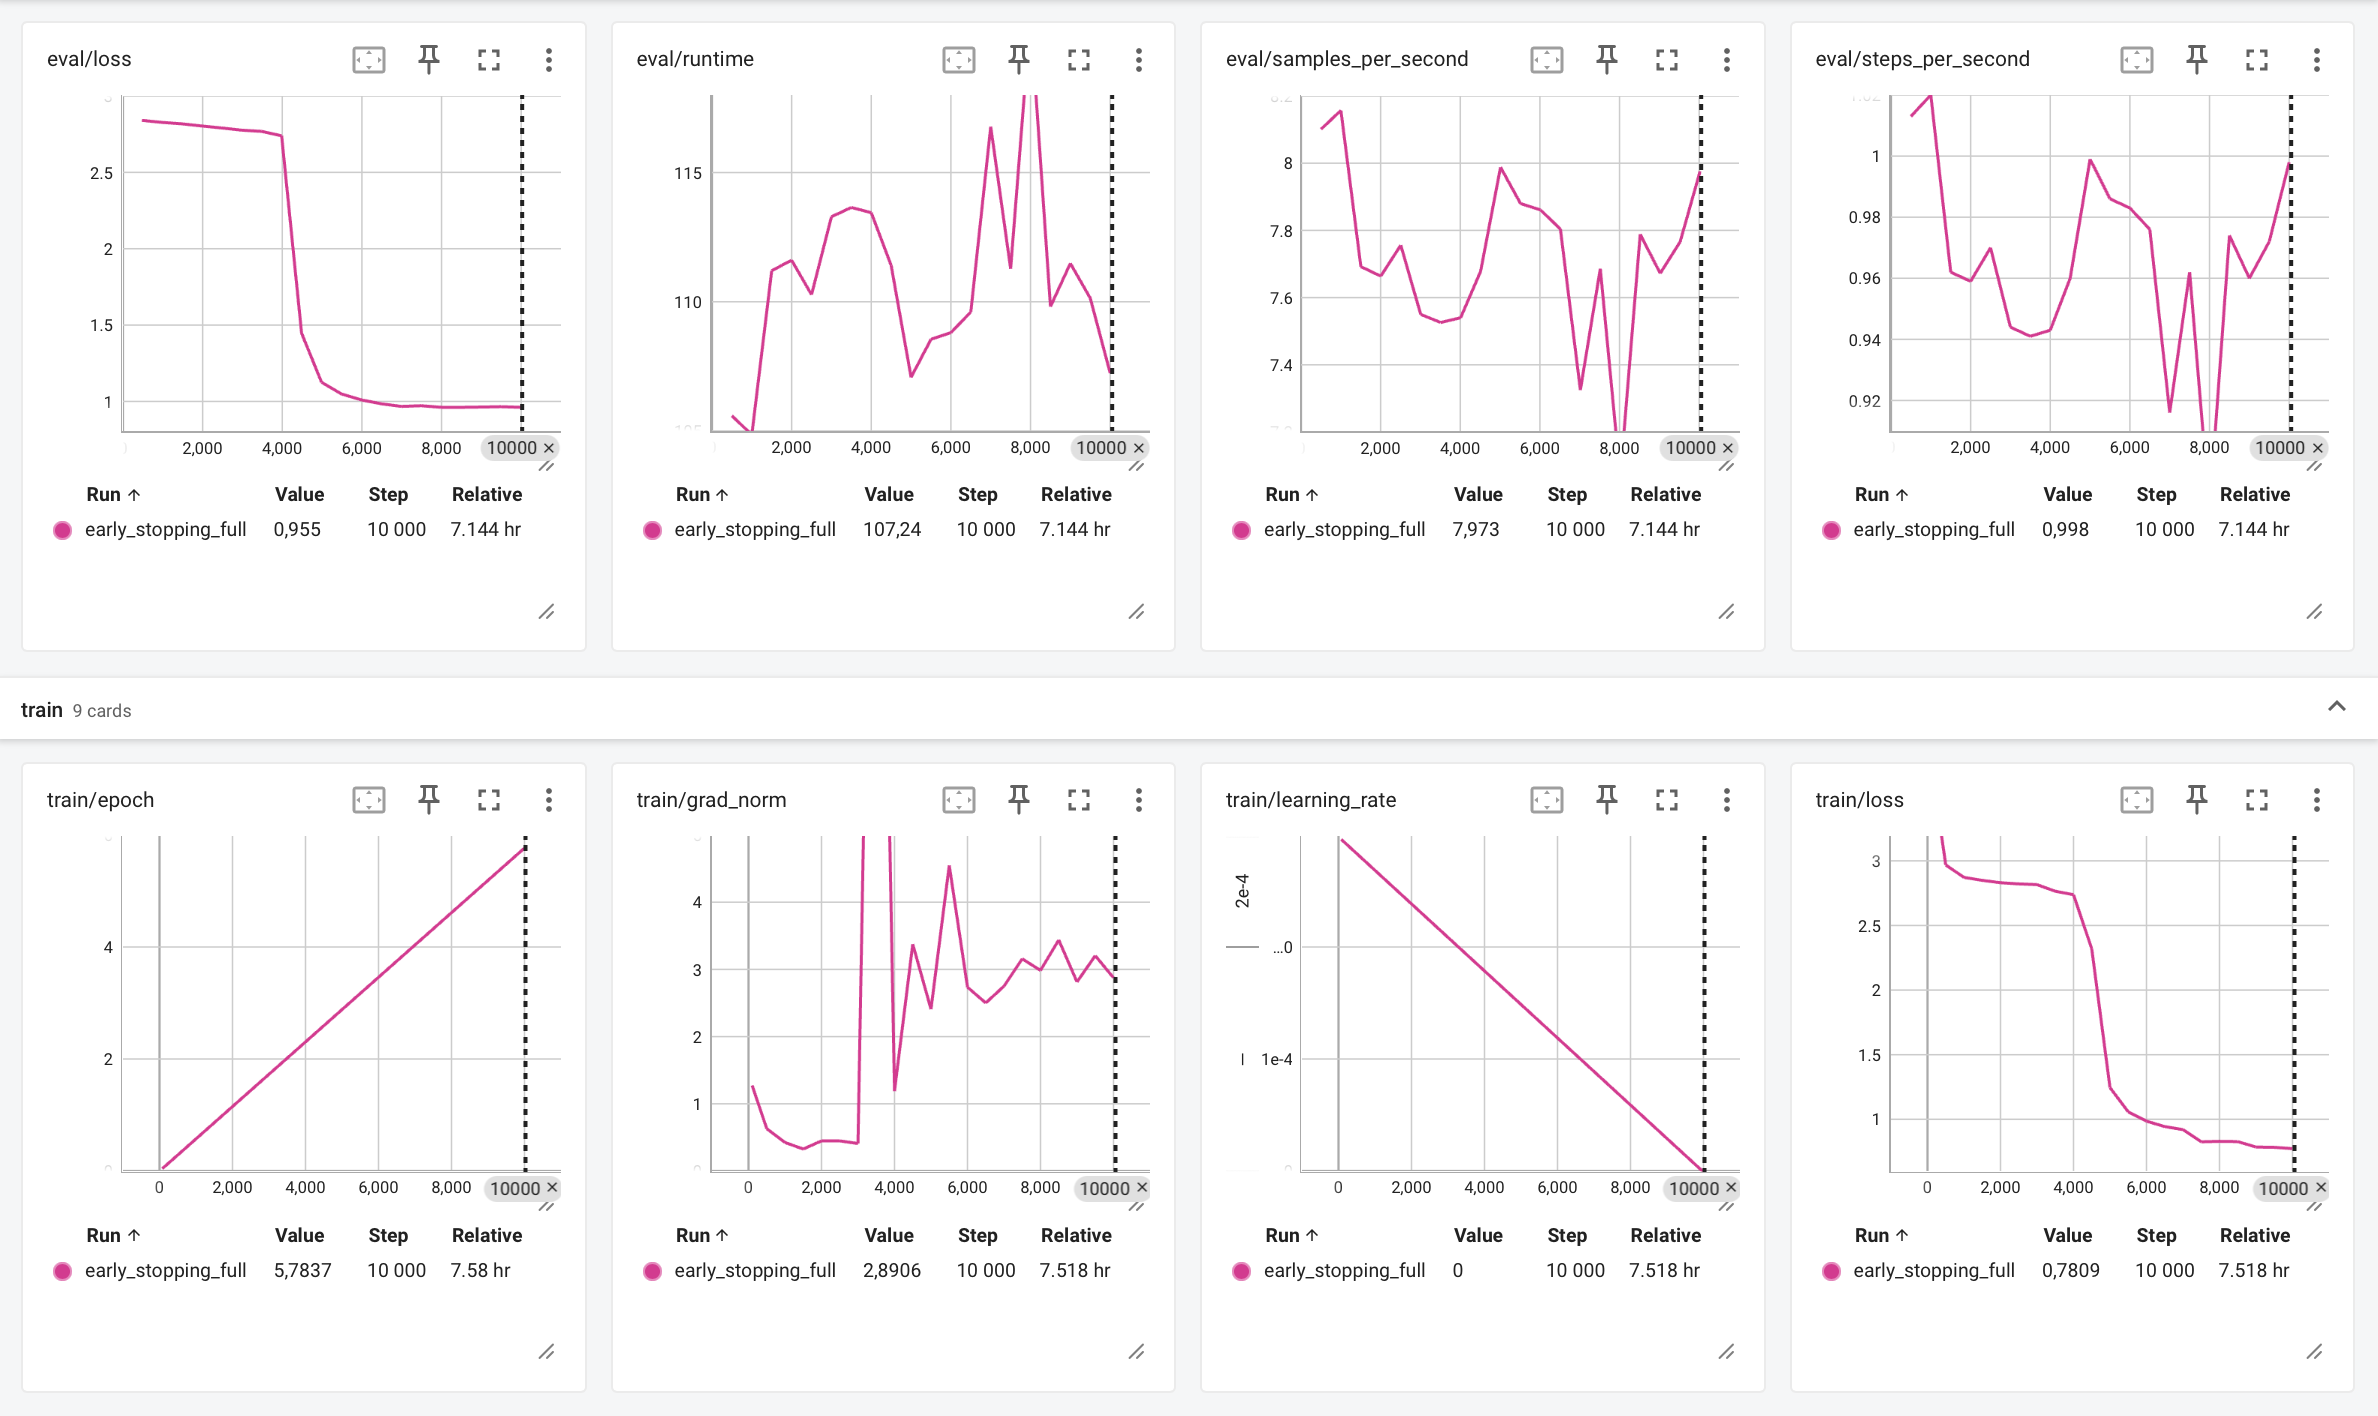